# Rendering


In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcad.render import Material, raymarch, render_raymarched
from jaxcad.sdf.boolean import Difference, Intersection, Union
from jaxcad.sdf.primitives import Box, Capsule, RoundBox, Sphere, Torus
from jaxcad.sdf.transforms import Translate

In [2]:
# ── Colour palette & scene defaults ──────────────────────────────────────────
# Named materials and defaults used consistently across every example.
M = {
    "blue": Material(color=[0.22, 0.50, 0.95], roughness=0.35),
    "red": Material(color=[0.93, 0.26, 0.22], roughness=0.70),
    "green": Material(color=[0.05, 0.72, 0.50], roughness=0.50),
    "gold": Material(color=[0.97, 0.76, 0.12], roughness=0.20, metallic=1.0),
    "purple": Material(color=[0.55, 0.25, 0.95], roughness=0.50),
    "white": Material(color=[0.84, 0.84, 0.82], roughness=0.95),
    "glass": Material(color=[0.92, 0.97, 1.0], roughness=0.05, opacity=0.1, ior=1.5),
}

bg = jnp.array([0.08, 0.10, 0.18])  # default scene background

## 1. Trace mode: `sphere` vs `bisection_refinement`

Two tracing strategies are available via `trace_mode`:

| Mode | How it works |
|---|---|
| `"sphere"` *(default)* | Standard sphere tracing — advances by the SDF value each step, stops at the closest approach. |
| `"bisection_refinement"` | Same coarse march, then uses a Newton step to bracket the surface zero-crossing and bisects to pin the exact hit. |

Both modes are compared with the **same total SDF-evaluation budget** (32):
- `sphere`: 32 march steps
- `bisection_refinement`: 24 march steps + 8 bisection steps

Bisection produces more accurate hit positions — visible as sharper silhouettes and crisper specular highlights on thin or curved geometry.

In [ ]:
import numpy as np

# Torus + small sphere: thin cross-section highlights hit-precision differences
torus = Torus(major_radius=0.9, minor_radius=0.18, material=M["gold"])
small = Translate(Sphere(radius=0.25, material=M["red"]), offset=jnp.array([0.9, 0.0, 0.0]))
scene_tm = Union((torus, small), smoothness=0.0)

cam_tm = jnp.array([0.0, 3.5, 3.5])
look_tm = jnp.array([0.0, 0.0, 0.0])
lights_tm = jnp.array([[1.0, 2.0, 1.0], [-0.8, 0.5, -0.6]])
lcolors_tm = jnp.array([[1.0, 0.92, 0.72], [0.25, 0.38, 0.70]])

# Both modes share the same total SDF-evaluation budget (32).
# sphere:               32 march steps
# bisection_refinement: 24 march steps + 8 bisection steps
BUDGET = 32
BISECT = 8

common_tm = {
    "camera_pos": cam_tm,
    "look_at": look_tm,
    "light_dirs": lights_tm,
    "light_colors": lcolors_tm,
    "background_color": bg,
    "resolution": (300, 300),
    "aa_samples": 2,
    "ambient": 0.04,
}

img_sphere = raymarch(scene_tm, trace_mode="sphere", max_steps=BUDGET, **common_tm)
img_bisect = raymarch(
    scene_tm,
    trace_mode="bisection_refinement",
    max_steps=BUDGET - BISECT,
    bisect_steps=BISECT,
    **common_tm,
)

diff = np.abs(img_bisect.astype(float) - img_sphere.astype(float))
diff_amplified = np.clip(diff * 20, 0, 1)

# ── Side-by-side + zoomed crop ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, img, title in zip(
    axes[0],
    [img_sphere, img_bisect, diff_amplified],
    [
        f"sphere  ({BUDGET} steps)",
        f"bisection_refinement\n({BUDGET - BISECT} march + {BISECT} bisect)",
        "|bisect − sphere| × 20",
    ],
):
    ax.imshow(img, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(title, fontsize=12)

# Crop: inner edge of the torus
r0, r1, c0, c1 = 100, 185, 125, 235
for ax, img in zip(axes[1], [img_sphere, img_bisect, diff_amplified]):
    ax.imshow(img[r0:r1, c0:c1], vmin=0, vmax=1, interpolation="nearest")
    ax.axis("off")
    ax.set_title("zoomed edge", fontsize=11)

plt.suptitle(f"Trace mode comparison  —  budget={BUDGET} SDF evals", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"max pixel diff: {diff.max():.6f}  mean: {diff.mean():.6f}")

## 2. Primitives side-by-side

Each primitive rendered from the same camera position.

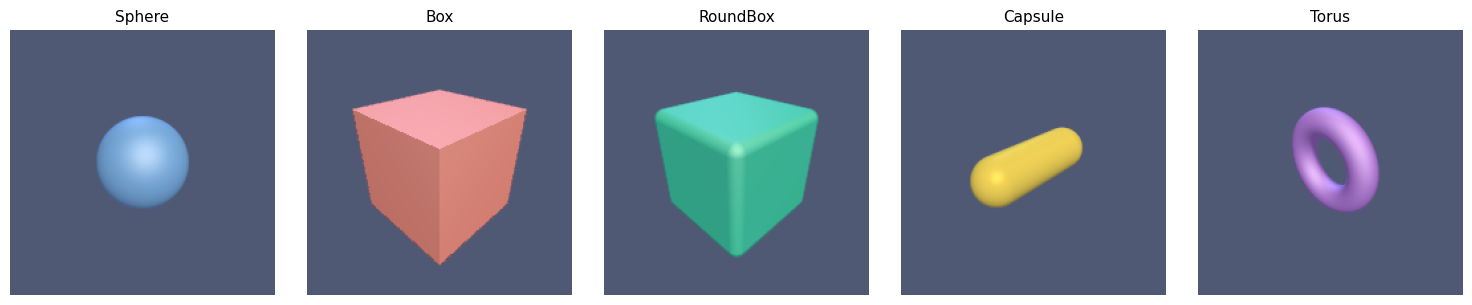

In [7]:
primitives = {
    "Sphere": Sphere(radius=1.0, material=M["blue"]),
    "Box": Box(size=[1.2, 1.2, 1.2], material=M["red"]),
    "RoundBox": RoundBox(size=[1.0, 1.0, 1.0], radius=0.2, material=M["green"]),
    "Capsule": Capsule(radius=0.5, height=1.0, material=M["gold"]),
    "Torus": Torus(major_radius=0.9, minor_radius=0.3, material=M["purple"]),
}

fig, axes = plt.subplots(1, len(primitives), figsize=(3 * len(primitives), 3))

cam = jnp.array([3.0, 2.5, 3.0])
light_dirs = jnp.array([[1.5, 2.0, 1.0], [-1.0, 0.5, -0.8]])
light_colors = jnp.array([[1.0, 0.92, 0.75], [0.25, 0.35, 0.65]])

for ax, (name, sdf) in zip(axes, primitives.items()):
    img = raymarch(
        sdf,
        camera_pos=cam,
        light_dirs=light_dirs,
        light_colors=light_colors,
        background_color=bg,
        resolution=(200, 200),
        aa_samples=1,
    )
    ax.imshow(img, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.show()

## 3. Boolean operations

Union, intersection, and difference of two overlapping shapes.

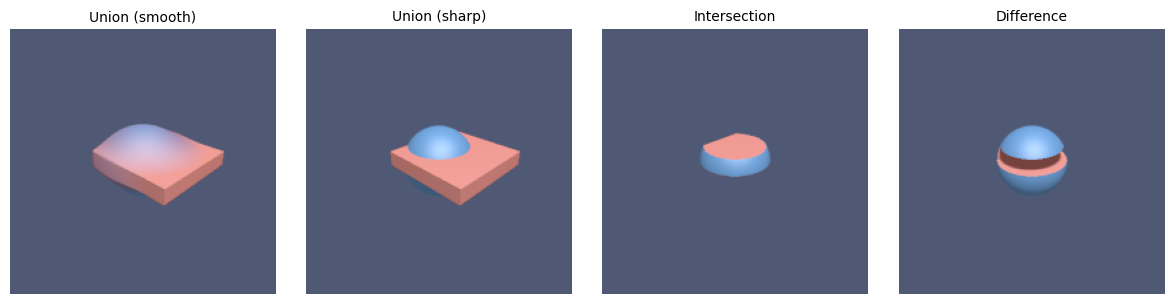

In [8]:
s = Sphere(radius=1.0, material=M["blue"])
b = Translate(Box(size=[1.2, 0.2, 1.2], material=M["red"]), offset=jnp.array([0.6, 0.3, 0.0]))

scenes = {
    "Union (smooth)": Union((s, b), smoothness=0.2),
    "Union (sharp)": Union((s, b), smoothness=0.0),
    "Intersection": Intersection((s, b), smoothness=0.0),
    "Difference": Difference((s, b), smoothness=0.0),
}

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
cam = jnp.array([4.0, 3.0, 4.0])

for ax, (name, scene) in zip(axes, scenes.items()):
    img = raymarch(scene, camera_pos=cam, background_color=bg, resolution=(200, 200), aa_samples=2)
    ax.imshow(img, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

## 4. Shadow hardness

The `shadow_hardness` parameter controls shadow edge sharpness.  
Low values give soft penumbra; high values give hard edges.

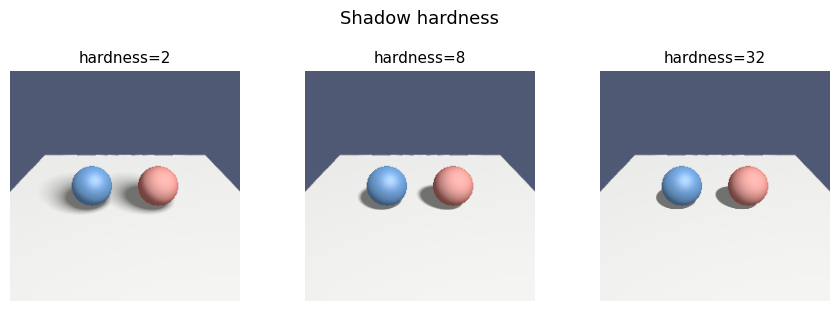

In [9]:
scene = Union(
    (
        Translate(Sphere(radius=0.6, material=M["blue"]), offset=jnp.array([-1.0, 0.0, 0.0])),
        Translate(Sphere(radius=0.6, material=M["red"]), offset=jnp.array([1.0, 0.0, 0.0])),
        Translate(
            Box(size=[4.0, 0.1, 4.0], material=M["white"]), offset=jnp.array([0.0, -0.7, 0.0])
        ),
    ),
    smoothness=0.0,
)

hardness_values = [2.0, 8.0, 32.0]
labels = [f"hardness={h:.0f}" for h in hardness_values]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
cam = jnp.array([0.0, 3.0, 5.0])
light = jnp.array([2.0, 4.0, 2.0])

for ax, h, label in zip(axes, hardness_values, labels):
    img = raymarch(
        scene,
        camera_pos=cam,
        light_dirs=light,
        background_color=bg,
        resolution=(250, 250),
        shadow_hardness=h,
        aa_samples=1,
    )
    ax.imshow(img, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(label, fontsize=11)

plt.suptitle("Shadow hardness", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Complex scene

A cluster of spheres smoothly blended together — the colour gradients at the joints are what make this visually striking.

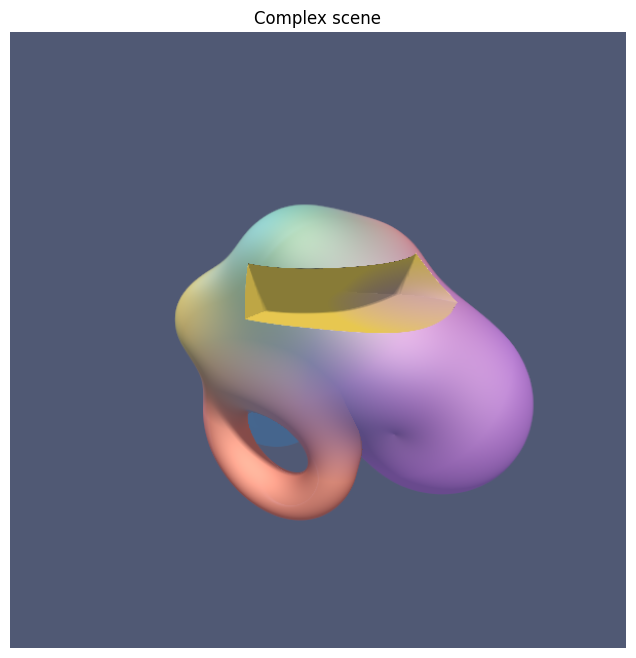

In [10]:
blob = Union(
    (
        Sphere(radius=0.80, material=M["blue"]),
        Translate(Sphere(radius=0.70, material=M["purple"]), offset=jnp.array([1.2, 0.2, 0.0])),
        Translate(Sphere(radius=0.60, material=M["red"]), offset=jnp.array([0.5, 0.9, -0.7])),
        Translate(Sphere(radius=0.50, material=M["gold"]), offset=jnp.array([-1.0, 0.4, 0.5])),
        Translate(Sphere(radius=0.40, material=M["green"]), offset=jnp.array([0.1, 1.3, 0.3])),
    ),
    smoothness=0.30,
)

blob = Difference(
    (
        blob,
        Translate(Box(size=[1.0, 0.3, 1.0], material=M["gold"]), offset=jnp.array([0.9, 1.0, 0.4])),
    ),
    smoothness=0.001,
)

rects = Union(
    (
        Translate(
            Torus(major_radius=0.9, minor_radius=0.3, material=M["red"]),
            offset=jnp.array([-0.2, -1.1, 0.4]),
        ),
        Translate(
            Torus(major_radius=0.3, minor_radius=0.9, material=M["purple"]),
            offset=jnp.array([1.5, -0.5, -0.6]),
        ),
        Translate(
            Torus(major_radius=0.9, minor_radius=0.3, material=M["blue"]),
            offset=jnp.array([-1.2, -0.8, -0.5]),
        ),
    ),
    smoothness=0.0,
)

scene = Union((blob, rects), smoothness=0.15)

render_raymarched(
    scene,
    camera_pos=jnp.array([3.5, 2.5, 5.0]),
    look_at=jnp.array([0.2, 0.2, 0.0]),
    light_dirs=jnp.array([[1.5, 3.0, 1.5], [-2.0, 1.0, -0.5]]),
    light_colors=jnp.array([[1.0, 0.88, 0.65], [0.30, 0.45, 0.80]]),
    background_color=bg,
    resolution=(600, 600),
    shadow_hardness=16.0,
    aa_samples=1,
    title="Complex scene",
)
plt.show()

## 6. Glass Refraction

When `ior > 1.0`, rays obey Snell's law at entry and exit:

1. Primary ray hits the front face → bends **into** the material.
2. Interior trace finds the back face (using `−sdf` as the distance field).
3. Ray bends back **into air** and continues through the scene.

The **Fresnel effect** (Schlick approximation) brightens edges at grazing angles.  
IOR sweep — air → water → glass → diamond.

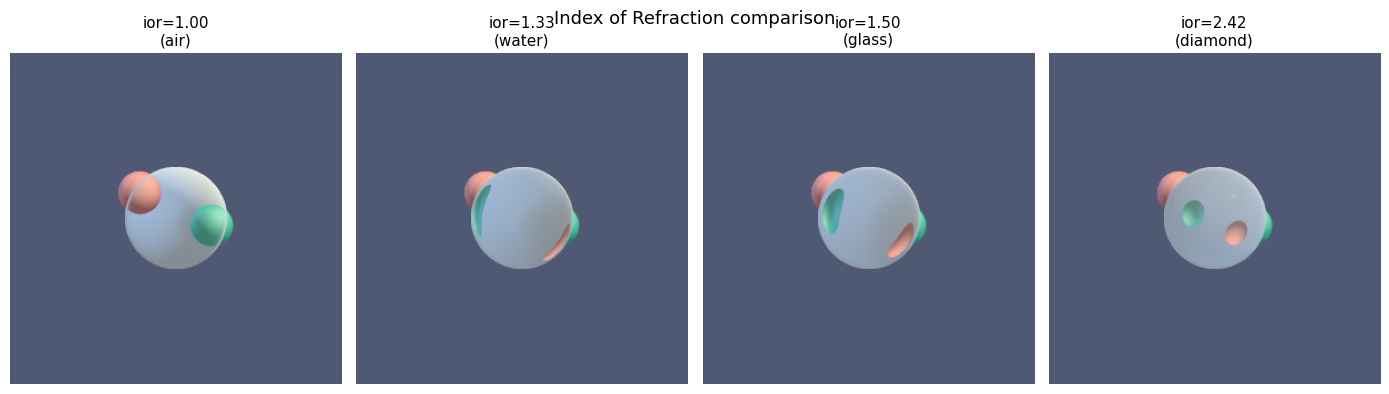

In [11]:
red_ball = Translate(Sphere(radius=0.65, material=M["red"]), offset=jnp.array([-1.1, 0.5, -3.0]))
green_ball = Translate(
    Sphere(radius=0.65, material=M["green"]), offset=jnp.array([1.1, -0.5, -3.0])
)

cam_glass = jnp.array([0.0, 0.5, 5.5])
look_glass = jnp.array([0.0, 0.0, 0.0])
lights_g = jnp.array([[1.5, 2.0, 1.0], [-1.0, 0.5, -0.8]])
lcolors_g = jnp.array([[1.0, 0.90, 0.70], [0.20, 0.35, 0.60]])


def render_glass(ior, res=300):
    scene = Union(
        (
            Sphere(
                radius=1.0,
                material=Material(color=[0.92, 0.97, 1.0], roughness=0.05, opacity=0.04, ior=ior),
            ),
            red_ball,
            green_ball,
        ),
        smoothness=0.0,
    )
    return raymarch(
        scene,
        camera_pos=cam_glass,
        look_at=look_glass,
        light_dirs=lights_g,
        light_colors=lcolors_g,
        resolution=(res, res),
        background_color=bg,
        refract_steps=48,
        max_steps=80,
        aa_samples=2,
        ambient=0.04,
    )


ior_cases = [
    (1.00, "ior=1.00\n(air)"),
    (1.33, "ior=1.33\n(water)"),
    (1.50, "ior=1.50\n(glass)"),
    (2.42, "ior=2.42\n(diamond)"),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (ior, label) in zip(axes, ior_cases):
    ax.imshow(render_glass(ior), vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(label, fontsize=11)

plt.suptitle("Index of Refraction comparison", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Mirror Reflections

Set `reflectivity > 0` on a material and pass `reflect_steps` to `raymarch`.
The reflected ray is sphere-traced for the given number of steps; if it hits
geometry it shades that surface, otherwise it falls back to the background.

`reflectivity` blends between the direct surface shading (`0`) and a perfect
mirror (`1`).  It is fully differentiable — `jax.grad` flows through it.

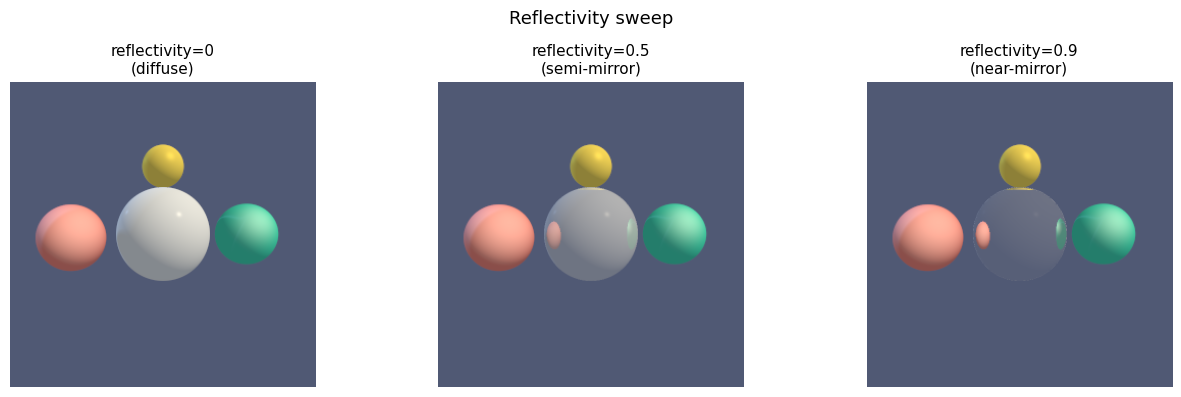

In [12]:
# ── Reflection sweep: reflectivity 0 → 0.5 → 0.9 ────────────────────────────
# Scene: coloured balls around a central chrome sphere.
ball_l = Translate(Sphere(radius=0.65, material=M["red"]), offset=jnp.array([-1.8, 0.0, 0.5]))
ball_r = Translate(Sphere(radius=0.65, material=M["green"]), offset=jnp.array([1.8, 0.0, 0.0]))
ball_t = Translate(Sphere(radius=0.55, material=M["gold"]), offset=jnp.array([0.0, 1.6, -1.5]))

cam_r = jnp.array([0.0, 0.8, 5.5])
look_r = jnp.array([0.0, 0.0, 0.0])
lights_r = jnp.array([[1.5, 2.0, 1.0], [-1.0, 0.5, -0.8]])
lcolors_r = jnp.array([[1.0, 0.90, 0.70], [0.20, 0.35, 0.60]])

reflectivity_cases = [
    (0.0, "reflectivity=0\n(diffuse)"),
    (0.5, "reflectivity=0.5\n(semi-mirror)"),
    (0.9, "reflectivity=0.9\n(near-mirror)"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (refl, label) in zip(axes, reflectivity_cases):
    sphere = Sphere(
        radius=1.0,
        material=Material(
            color=[0.85, 0.88, 0.92],
            roughness=0.05,
            reflectivity=refl,
        ),
    )
    scene = Union((sphere, ball_l, ball_r, ball_t), smoothness=0.0)
    img = raymarch(
        scene,
        camera_pos=cam_r,
        look_at=look_r,
        light_dirs=lights_r,
        light_colors=lcolors_r,
        background_color=bg,
        resolution=(300, 300),
        max_steps=64,
        reflect_steps=32,
        aa_samples=2,
        ambient=0.04,
    )
    ax.imshow(img, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(label, fontsize=11)

plt.suptitle("Reflectivity sweep", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Environment Maps (HDR backgrounds & reflections)

Pass an `env_map` array of shape `(H, W, 3)` to `raymarch` to replace the flat
`background_color` with a direction-dependent environment:

* **Primary misses** sample the map using the ray direction.
* **Reflection misses** sample using the *reflected* ray direction, giving correct
  env-lit mirror surfaces.

Any real HDR file works:

```python
import imageio.v3 as iio
env = jnp.asarray(iio.imread("studio.hdr"), dtype=jnp.float32)
```

The helper `make_gradient_sky()` generates a procedural sky gradient so you can
try the feature without an external file.

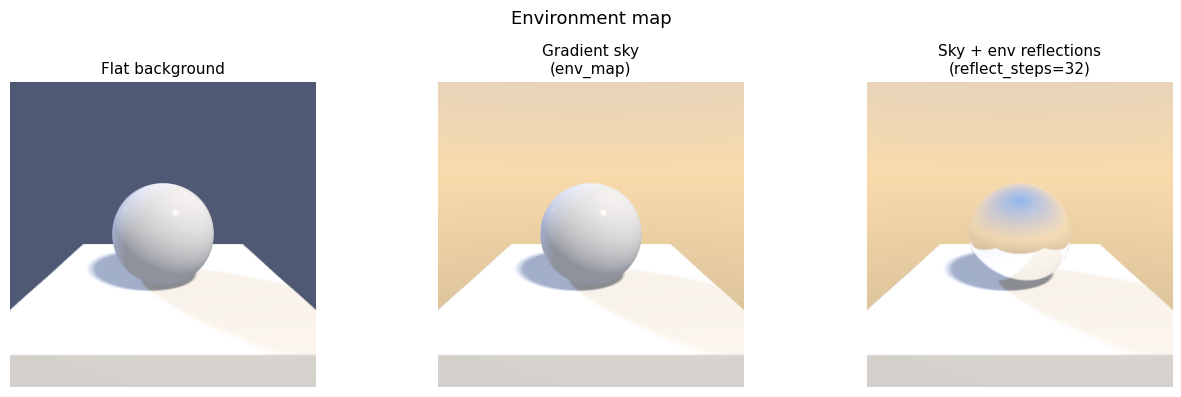

In [13]:
from jaxcad.render import make_gradient_sky

# Procedural sky — swap this for jnp.asarray(iio.imread("your_file.hdr")) to
# use a real HDR image.
sky = make_gradient_sky(
    sky_color=[0.18, 0.42, 0.88],
    horizon_color=[0.95, 0.72, 0.42],
    ground_color=[0.22, 0.18, 0.14],
    resolution=(256, 512),
)

# ── Three panels: flat bg | sky bg | sky bg + mirror reflection ──────────────
chrome = Sphere(
    radius=1.0,
    material=Material(
        color=[0.90, 0.92, 0.95],
        roughness=0.05,
        reflectivity=0.85,
    ),
)
pedestal = Translate(
    Box(size=[2.4, 0.3, 2.4], material=M["white"]),
    offset=jnp.array([0.0, -1.2, 0.0]),
)
scene_env = Union((chrome, pedestal), smoothness=0.0)

cam_e = jnp.array([0.0, 1.2, 5.0])
look_e = jnp.array([0.0, 0.0, 0.0])
lights_e = jnp.array([[1.0, 2.0, 1.0], [-0.8, 0.4, -0.6]])
lcolors_e = jnp.array([[1.0, 0.92, 0.80], [0.25, 0.38, 0.70]])

common_e = {
    "camera_pos": cam_e,
    "look_at": look_e,
    "light_dirs": lights_e,
    "light_colors": lcolors_e,
    "resolution": (300, 300),
    "max_steps": 64,
    "aa_samples": 2,
    "ambient": 0.06,
}

img_flat = raymarch(scene_env, background_color=bg, **common_e)
img_sky = raymarch(scene_env, env_map=sky, **common_e)
img_refl = raymarch(scene_env, env_map=sky, reflect_steps=32, **common_e)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, img, title in zip(
    axes,
    [img_flat, img_sky, img_refl],
    ["Flat background", "Gradient sky\n(env_map)", "Sky + env reflections\n(reflect_steps=32)"],
):
    ax.imshow(img, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(title, fontsize=11)

plt.suptitle("Environment map", fontsize=13)
plt.tight_layout()
plt.show()